# Calibração pelo campo, CIELAB e k-means

Uma segmentação por cor: cada pixel colorido da foto tem que cair na classe certa (amarelo, azul, vermelho...). O caminho é simular a luz, calibrar pelo próprio campo, converter pra CIELAB e agrupar com k-means em L\*a\*b\*.

```
foto ─► simula a luz ─► calibração ─► CIELAB ─► k-means em L*a*b* ─► IoU contra o gabarito
```



## Balanço de branco e preto pelo campo

Trocar a lâmpada, antes do gama, é isso: cada canal do sensor é reescalado, mais um véu de luz ambiente somado:

$$x^{obs}_c = g_c\,x^{real}_c + o_c$$

Uma reta por canal, duas incógnitas — bastam duas superfícies de valor já conhecido. Por isso basta desfazer o gama antes de tudo: em sRGB o ganho deixa de ser multiplicativo.

Cartela de cores não tem, mas o campo dá as duas superfícies sozinho: o **piso escuro**, referência de preto, e as **linhas claras**, referência de branco. Aparecem em toda foto, cobrem milhares de pixels, e como uma é escura e a outra clara, o ganho sai estável — não explode com ruído. Com $p$ = piso e $l$ = linhas, em RGB linear:

$$\textbf{ganho}_c=\frac{l^{ref}_c-p^{ref}_c}{l^{obs}_c-p^{obs}_c},\qquad
\textbf{desloc}_c=p^{ref}_c-\textbf{ganho}_c\,p^{obs}_c,\qquad
x^{cal}=\textbf{ganho}\cdot x^{obs}+\textbf{desloc}$$

Refeita em cada imagem, com os pixels dela mesma — nada treinado. Pixel estourado fica de fora.

CIELAB entra depois porque, nesse espaço, distância euclidiana é próxima da distância que a gente enxerga — o que o k-means minimiza. Sem calibrar, a luz bagunça o L\*; calibrado, ele volta à escala certa e ajuda a separar as cores.

In [17]:
import numpy as np, pandas as pd, cv2, colour, matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from scipy.spatial.distance import pdist
from skimage.color import rgb2lab
from sklearn.cluster import KMeans

DADOS = Path('dados_2020')
SAIDA = Path('saidas'); SAIDA.mkdir(exist_ok=True)
REFERENCIA = DADOS/'test_images/image0000.jpg'   # foto sob a luz normal do laboratório
GABARITO   = DADOS/'gabarito.png'                # etiquetas pintadas, uma cor por classe

TEMPS   = (2700, 3500, 4500, 5500, 6500, 8000)   # temperatura da luz simulada, em K
ESCALAS = (0.4, 0.7, 1.0)                        # intensidade da luz
K, AMOSTRAS, SEMENTE = 12, 6000, 0               # k-means
CROMA_MIN, FATOR = 18., .5                       # abaixo do croma mínimo é piso; grupo longe demais de toda cor vira fundo

CORES = ('fundo', 'amarelo', 'azul', 'verde', 'vermelho', 'rosa', 'bola')
AVAL  = (1, 2, 4)                                # só amarelo, azul e vermelho entram na nota
PALETA = np.array([[0,0,0], [252,251,2], [1,0,250], [7,241,8],
                   [201,13,16], [229,32,138], [243,168,4]], 'uint8')

def ler(caminho):
    return cv2.cvtColor(cv2.imread(str(caminho)), cv2.COLOR_BGR2RGB)

ref = ler(REFERENCIA)
gabarito = ((ler(GABARITO)[..., None, :].astype(int) - PALETA)**2).sum(-1).argmin(-1).astype('uint8')
print('foto de %d x %d pixels, gabarito com %d classes' % (ref.shape[1], ref.shape[0], len(np.unique(gabarito))))

foto de 656 x 516 pixels, gabarito com 7 classes


In [18]:
# desfazer o gama e simular outra luz
def para_linear(img):
    """sRGB de volta pro linear. É só aqui que a luz age como um ganho simples."""
    s = np.asarray(img, np.float32)/255
    return np.where(s <= .04045, s/12.92, ((s + .055)/1.055)**2.4)

def para_srgb(lin):
    x = np.clip(lin, 0, 1)
    s = np.where(x <= .0031308, 12.92*x, 1.055*x**(1/2.4) - .055)
    return np.clip(255*s + .5, 0, 255).astype('uint8')

def ganho_da_luz(T, base=6500.):
    """Quanto cada canal muda ao trocar a luz de `base` kelvin por T kelvin."""
    def rgb(t):
        xy = colour.CCT_to_xy(float(t), method='Kang 2002')
        return colour.XYZ_to_RGB(colour.xy_to_XYZ(xy), 'sRGB', chromatic_adaptation_transform=None)
    g = rgb(T)/rgb(base)
    return (g/g[1]).astype('float32')            # normalizado no verde

GANHO = {t: ganho_da_luz(t) for t in TEMPS}

def simula(img, T, escala):
    """A foto como a câmera a veria sob a luz T, `escala` vezes mais forte (ou mais fraca)."""
    return para_srgb(para_linear(img)*GANHO[T]*escala)

print('ganho de cada canal por temperatura (em relação a 6500 K):')
print(pd.DataFrame(GANHO, index=['R','G','B']).T.round(3))

ganho de cada canal por temperatura (em relação a 6500 K):
          R    G      B
2700  2.261  1.0  0.228
3500  1.653  1.0  0.431
4500  1.297  1.0  0.657
5500  1.111  1.0  0.844
6500  1.000  1.0  1.000
8000  0.901  1.0  1.186


In [19]:
# o que o campo oferece: área útil, âncoras da calibração e cor de cada etiqueta
lab_ref = rgb2lab(ref)

# o campo é a maior mancha escura da foto; fecho os buracos e puxo a borda 45 px pra dentro
escuro = cv2.morphologyEx((lab_ref[...,0] < 45).astype('uint8'), cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17,17)))
_, cc, stats, _ = cv2.connectedComponentsWithStats(escuro)
cnts, _ = cv2.findContours((cc == 1 + stats[1:, cv2.CC_STAT_AREA].argmax()).astype('uint8'),
                           cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
campo = np.zeros(gabarito.shape, 'uint8')
cv2.drawContours(campo, [cv2.convexHull(max(cnts, key=cv2.contourArea))], -1, 1, -1)
campo = cv2.erode(campo, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (45,45))).astype(bool)

# âncoras: piso escuro e linhas claras, com 28 px de folga pra não encostarem nas etiquetas
longe  = ~cv2.dilate((gabarito > 0).astype('uint8'),
                     cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (57,57))).astype(bool)
PISO   = campo & longe & (lab_ref[...,0] < 45)
LINHAS = campo & longe & (lab_ref[...,0] > 70)

inteiro = ref.max(-1) < 250                      # pixel estourado não entra na conta
ALVO = np.stack([np.median(para_linear(ref)[m & inteiro], 0) for m in (PISO, LINHAS)])

# cor de referência de cada etiqueta: a mediana da região anotada aguenta bem as bordas
regiao = {c: (gabarito == c) & campo for c in range(1, 7)}
NOMES  = np.array([c for c in regiao if regiao[c].any()], 'uint8')
REFS   = np.stack([np.median(lab_ref[regiao[c]], 0) for c in NOMES])

print('campo útil: %d px  |  piso: %d px  |  linhas: %d px\n' % (campo.sum(), PISO.sum(), LINHAS.sum()))
print('cor de referência de cada etiqueta, em L*a*b*:')
print(pd.DataFrame(REFS.round(1), index=[CORES[c] for c in NOMES], columns=['L*','a*','b*']))

campo útil: 261706 px  |  piso: 155838 px  |  linhas: 3896 px

cor de referência de cada etiqueta, em L*a*b*:
            L*    a*    b*
amarelo   84.4 -11.0  42.1
azul      69.7  -5.4 -45.5
verde     70.5 -24.5   9.1
vermelho  53.2  70.2  28.1
rosa      73.4  24.1  -7.7
bola      68.2  39.2  69.7


In [20]:
# calibração, k-means e nota
def reta_do_campo(img):
    """Ganho e deslocamento por canal, ajustados nas duas âncoras desta imagem."""
    lin = para_linear(img)
    inteiro = img.max(-1) < 250
    piso, linhas = (np.median(lin[m & inteiro], 0) for m in (PISO, LINHAS))
    ganho = (ALVO[1] - ALVO[0])/(linhas - piso)
    return ganho, ALVO[0] - ganho*piso

def calibra(img):
    ganho, desloc = reta_do_campo(img)
    return para_srgb(para_linear(img)*ganho + desloc)

def segmenta(img):
    """k-means em L*a*b* nos pixels coloridos do campo; cada grupo vira a cor de referência mais próxima."""
    lab = rgb2lab(img)
    pontos = np.flatnonzero(campo & (np.linalg.norm(lab[...,1:], axis=-1) >= CROMA_MIN))
    X = lab.reshape(-1, 3)[pontos].astype('float32')

    sorteio = np.random.default_rng(SEMENTE).choice(len(X), min(len(X), AMOSTRAS), replace=False)
    km = KMeans(K, n_init=3, random_state=SEMENTE).fit(X[sorteio])

    d = np.linalg.norm(km.cluster_centers_[:,None] - REFS[None], axis=-1)
    rotulo = NOMES[d.argmin(1)]
    rotulo[d.min(1) > FATOR*np.median(pdist(REFS))] = 0      # longe de todas as cores -> fundo

    pred = np.zeros(campo.shape, 'uint8')
    pred.ravel()[pontos] = rotulo[km.predict(X)]
    return pred

def iou(pred, c):
    a, b = (pred == c) & campo, (gabarito == c) & campo
    uniao = (a | b).sum()
    return float((a & b).sum()/uniao) if uniao else np.nan

In [21]:
# cada condição de luz passa pelos dois caminhos: sem calibrar e calibrado
registros = []
for T, escala in product(TEMPS, ESCALAS):
    obs = simula(ref, T, escala)
    for calibracao, img in (('sem', obs), ('campo', calibra(obs))):
        pred = segmenta(img)
        r = dict(T=T, escala=escala, calibracao=calibracao)
        r.update({'iou_' + CORES[c]: iou(pred, c) for c in AVAL})
        r['miou'] = float(np.nanmean([r['iou_' + CORES[c]] for c in AVAL]))
        registros.append(r)
    print('.', end='', flush=True)

seg = pd.DataFrame(registros)
seg.to_csv(SAIDA/'kmeans.csv', index=False)
print('\npronto: %d condições de luz, sem e com calibração' % (len(TEMPS)*len(ESCALAS)))

..................
pronto: 18 condições de luz, sem e com calibração


In [22]:
print('mIoU média (quanto maior, melhor):\n')
print(seg.groupby('calibracao').miou.mean().loc[['sem','campo']].round(4).to_string())

p = seg.pivot_table(index=['T','escala'], columns='calibracao', values='miou')
dif = p['campo'] - p['sem']
print('\ncalibrar mudou o mIoU em %+.3f, em média (desvio %.3f)' % (dif.mean(), dif.std()))
print('e melhorou em %.0f%% das %d condições' % ((dif > 0).mean()*100, len(dif)))

mIoU média (quanto maior, melhor):

calibracao
sem      0.4502
campo    0.5750

calibrar mudou o mIoU em +0.125, em média (desvio 0.272)
e melhorou em 56% das 18 condições


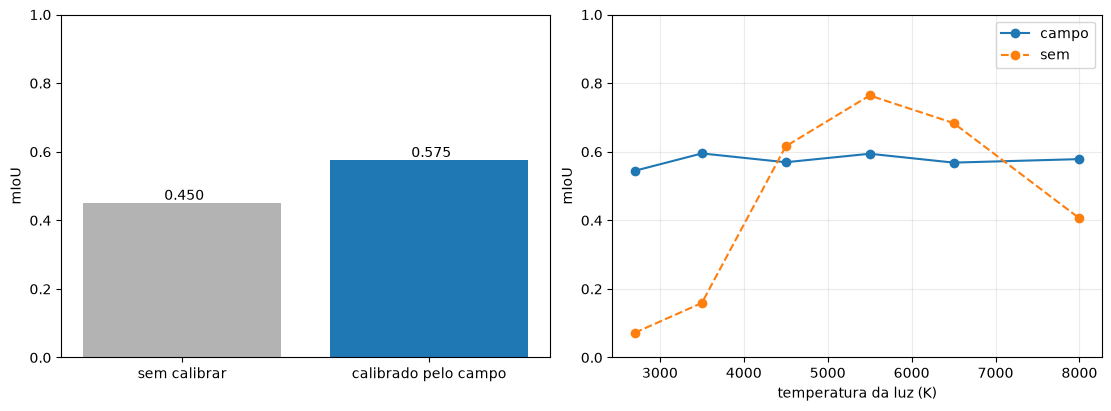

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11,4), layout='constrained')
m = seg.groupby('calibracao').miou.mean()
ax[0].bar(['sem calibrar', 'calibrado pelo campo'], [m['sem'], m['campo']], color=['.7', '#1f77b4'])
for i, h in enumerate([m['sem'], m['campo']]): ax[0].text(i, h, ' %.3f' % h, ha='center', va='bottom')
ax[0].set_ylabel('mIoU'); ax[0].set_ylim(0,1)

for c, v in seg.groupby('calibracao'):
    ax[1].plot(v.groupby('T').miou.mean(), 'o-' if c == 'campo' else 'o--', label=c)
ax[1].set_xlabel('temperatura da luz (K)'); ax[1].set_ylabel('mIoU'); ax[1].set_ylim(0,1)
ax[1].legend(); ax[1].grid(alpha=.25)
fig.savefig(SAIDA/'resultado.png', dpi=180); plt.show()

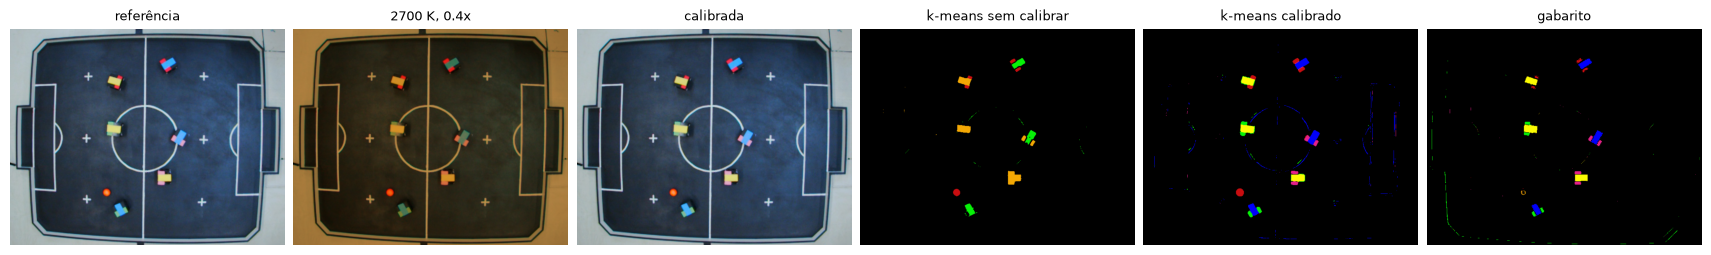

a calibração desfez a luz com ganho [  1.11   2.49  10.92] e deslocamento [-0.0005 -0.     -0.0005]


In [16]:
# e como isso fica na foto, na condição mais dura: luz bem quente e fraca
T, escala = TEMPS[0], ESCALAS[0]
obs = simula(ref, T, escala)
cal = calibra(obs)

painel = [(ref, 'referência'), (obs, f'{T} K, {escala}x'), (cal, 'calibrada'),
          (PALETA[segmenta(obs)], 'k-means sem calibrar'),
          (PALETA[segmenta(cal)], 'k-means calibrado'),
          (PALETA[gabarito], 'gabarito')]

fig, ax = plt.subplots(1, 6, figsize=(17,3.2), layout='constrained')
for a, (im, titulo) in zip(ax, painel):
    a.imshow(im); a.set_title(titulo, fontsize=9); a.axis('off')
fig.savefig(SAIDA/'exemplo.png', dpi=180); plt.show()

ganho, desloc = reta_do_campo(obs)
print('a calibração desfez a luz com ganho', ganho.round(2), 'e deslocamento', desloc.round(4))